# **Particle trajectories along the turbulent magnetic field lines**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from field_lines import PeriodicInterpolator, integrate_lines, unwrap_lines, plot_field_lines
from generate_kolmogorov import get_iso_cube, set_cubes

## 1. Brief theoretical description

In the UrL,


$$
\begin{cases}
    \frac{d\cos\alpha}{dt} = \frac{\sin^2\alpha}{2B}\frac{dB}{ds},\\

    \frac{ds}{dt} = \cos\alpha.
\end{cases}
$$

As soon as we know the MF configuration, we calculate particle propagation for different initial angles.

## 2. Magnetic field line

### 2.1. Cube

In [2]:
L = 300  # [pc], half-size
n_side = 256
dx = 2*L/n_side # [pc], cell size
k_min = 2*np.pi / (2*L)  # [pc-1], injection scale
print(f"Each cell is a cube with size dx = {dx:.2f} pc")
print(f"Injection scale (2pi/k_min) is {2*np.pi/k_min:.2f} pc")

r_cube, k_cube = set_cubes(n_side, L)

Each cell is a cube with size dx = 2.34 pc
Injection scale (2pi/k_min) is 600.00 pc


In [ ]:
b_cube = get_iso_cube(n_side, L, power_index=11/3, k_min=k_min)  # normalized isotropic field

In [4]:
eta = 1.0

b0 = 1 / np.sqrt(1 + eta**2)

b_turb = eta / np.sqrt(1 + eta**2) * b_cube

b_cube_10 = b_turb
b_cube_10[2] += b0

### 2.2. Lines

In [5]:
periodic_interpolator = PeriodicInterpolator(r_cube, b_cube_10)

In [6]:
M = 40
ds = dx / 5
n_steps = int(2 * L / ds)  # n_steps
N_steps = 2 * n_steps + 1

# calculate field lines
lines = integrate_lines(periodic_interpolator, M, n_steps, ds)

# calculate magnetic fields along the line
fields = np.zeros([2*n_steps + 1, M, 3])
for i in range(M):
    fields[:, i, :] = periodic_interpolator(lines[:, i])

# now shift the lines to 0
lines_from_zero = unwrap_lines(lines - lines[n_steps], 2 * L)

In [7]:
print(n_steps)

1280


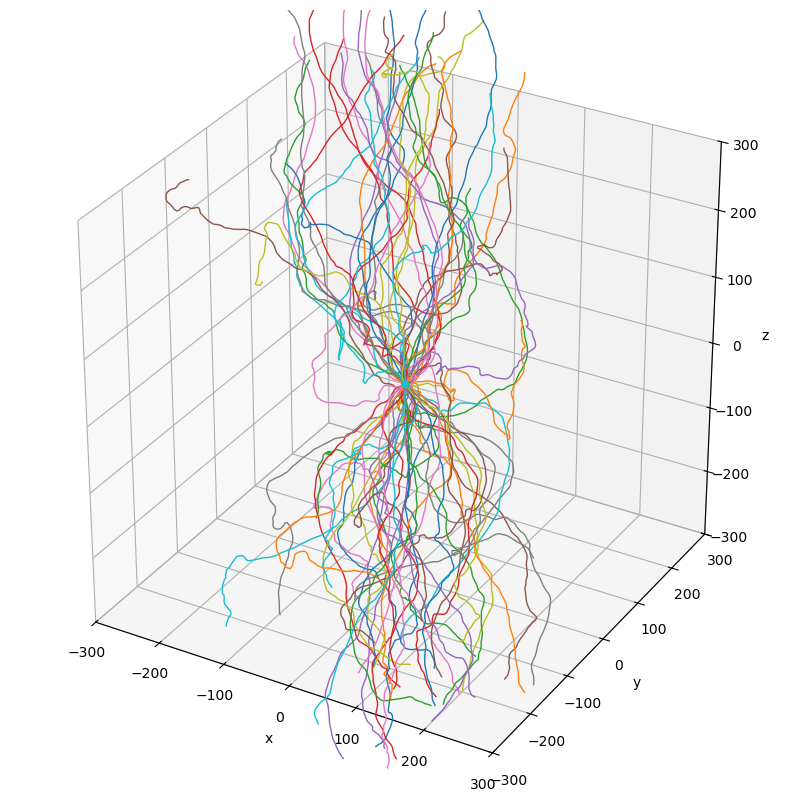

In [8]:
plot_field_lines(
    lines_from_zero,
    n_lines=M,
    box_size=L
)
plt.tight_layout()
plt.show()

In [9]:
s_line = np.linspace(-ds * n_steps, ds * n_steps, N_steps)
field_strengths = np.linalg.norm(fields, axis=2)

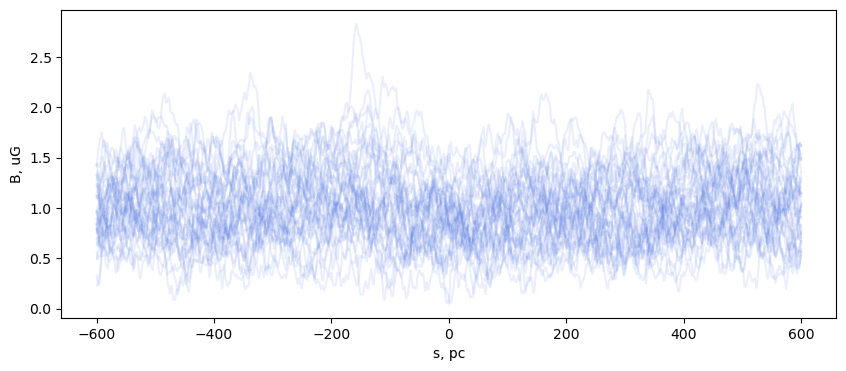

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(s_line, field_strengths, alpha=0.1, color='royalblue')
plt.xlabel("s, pc")
plt.ylabel("B, uG")
plt.show()

## 3. Particle propagation

Solve a system of two equation (set $\mu = \cos\alpha$).

1. $ \dfrac{ds}{dt} = \mu, $

2. $ \dfrac{d\mu}{dt} = -\dfrac{1-\mu^2}{2B} \dfrac{dB}{ds}. $

This system can be significantly simplified by introducing invariant quantity

$I_0 = \dfrac{\sin^2\alpha}{2B} = \dfrac{1-\mu^2}{2B} = const $

The system becomes

1. $ \dfrac{ds}{dt} = \mu, $

2. $ \dfrac{d\mu}{dt} = -I_0 \dfrac{dB}{ds}. $

If we now introduce a pair $(s, \mu)$ and a ''potential'' $U = I_0 B$, we obtain a hamiltonian system!

1. $ \dfrac{ds}{dt} = \mu,$

2. $ \dfrac{d\mu}{dt} = -\dfrac{dU}{ds}. $

For that kind of system, we want to use *a symplectic integrator*, which is suited for Hamiltonian problems

In [11]:
from scipy.interpolate import PchipInterpolator

splines = []
integrals = []


for m in range(M):
    field_st = field_strengths[:, m]
    B_spline = PchipInterpolator(s_line, field_st)
    splines.append(B_spline)

In [12]:
def verlet_step(s, mu, I0, dt, dBds):
    mu_half = mu - 0.5 * dt * I0 * dBds(s)
    
    s_new = s + dt * mu_half
    
    mu_new = mu_half - 0.5 * dt * I0 * dBds(s_new)
    
    return s_new, mu_new

In [27]:
m_0 = 15  # index of the field line to use
N_p = 100  # number of particles

mu_p = np.linspace(-1, 1, N_p)  # random (spherical) distribution in local pitch-angle
s_p = np.zeros(N_p)  # initial position of the particles

integrals_p = (1 - mu_p**2) / (2 * splines[m_0](s_p))  # initial value of the integral of motion

In [28]:
N_particle_steps = n_steps * 10
dt = ds / 10  # time step for the particle integration
times = np.arange(N_particle_steps) * dt   # time array (in pc as c = 1)

trajectories = np.zeros((N_particle_steps, N_p))
angles = np.zeros((N_particle_steps, N_p))

trajectories[0] = s_p
angles[0] = mu_p

for step in range(1, N_particle_steps):
    dBds = splines[m_0].derivative()
    s_p, mu_p = verlet_step(s_p, mu_p, integrals_p, dt, dBds)
    trajectories[step] = s_p
    angles[step] = mu_p

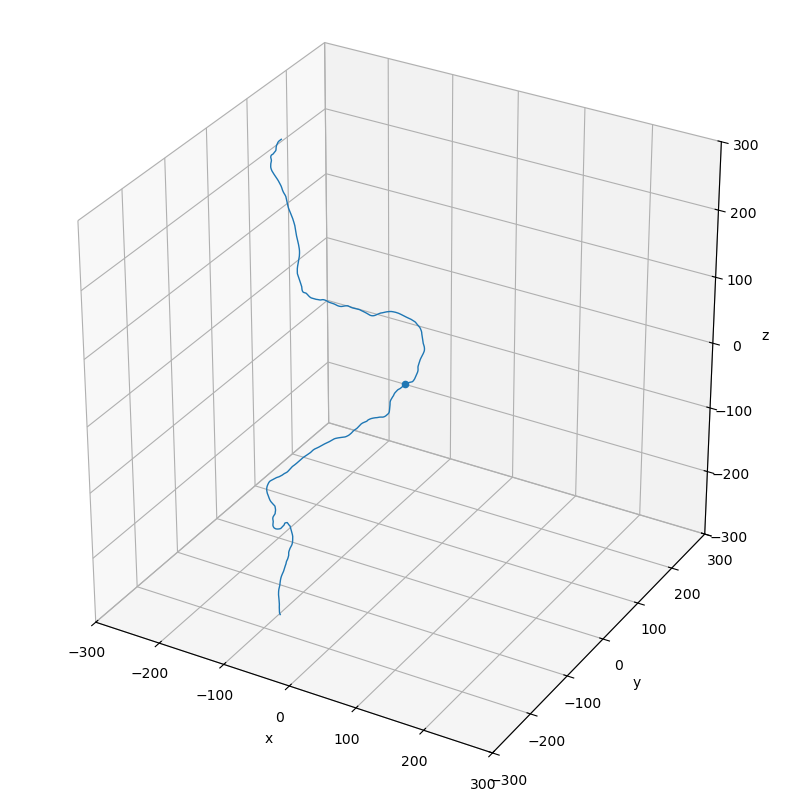

In [29]:
plot_field_lines(
    lines_from_zero[:, m_0:m_0+1],
    n_lines=1,
    box_size=L
)
plt.tight_layout()
plt.show()

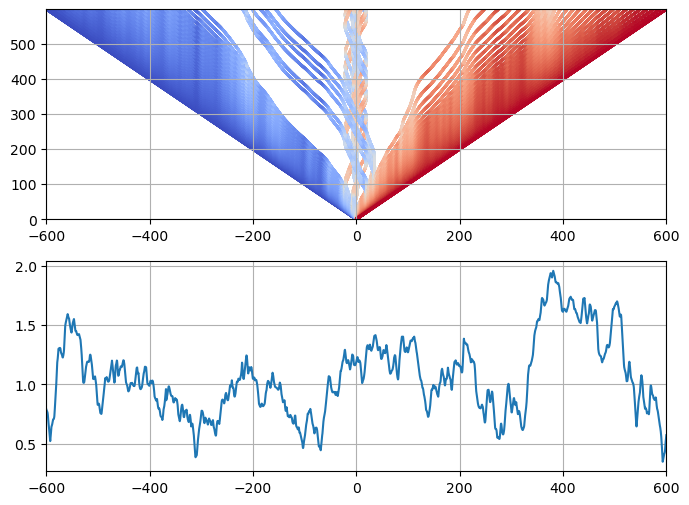

In [30]:
plt.figure(figsize=(8, 6))
plt.subplot(211)
for k in range(0, N_p):
    plt.scatter(trajectories[::4, k], times[::4], s=1, c=angles[::4, k], vmin=-1, vmax=1, cmap='coolwarm')
# plt.colorbar(label='Pitch-angle cosine')
plt.xlim(-2*L, 2*L)
plt.ylim(0, times[-1])
plt.grid()

plt.subplot(212)
plt.plot(s_line, field_strengths[:, m_0])
plt.xlim(-2*L, 2*L)
plt.grid()
plt.show()

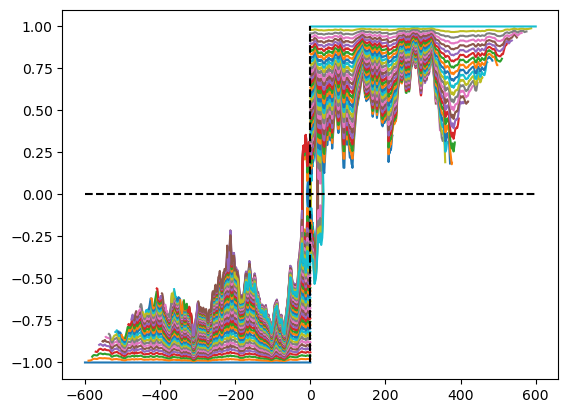

In [31]:
for k in range(0, N_p):
    plt.plot(trajectories[::4, k], angles[::4, k], label=f'Particle {k}')
plt.hlines([0], -2*L, 2*L, colors='k', linestyles='dashed', label='mu=0')
plt.vlines([0], -1, 1, colors='k', linestyles='dashed', label='s=0')

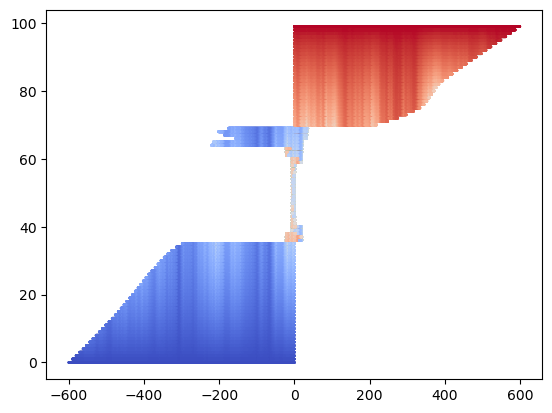

In [32]:
for k in range(0, N_p):
    plt.scatter(trajectories[::4, k], np.ones(N_particle_steps//4) * k, s=1, c=angles[::4, k], vmin=-1, vmax=1, cmap='coolwarm')

## 4. Observed geometry

At each point along the line with a tangent vector $\mathbf{u}$, we search for $\hat{R}$, such that $\hat{R}\mathbf{u} = \hat{z}$.

It is defined by Rodriguez rotation formula:

1. axis: $ \vec{a} = \dfrac{\vec{u}\times\hat{z}}{|\vec{u}\times\vec{z}|} $

2. skew-symmetric $\vec{a}$-based matrix $K$

3. angle: $\theta = \arccos(\hat{u}\cdot\hat{z})$

4. rotation matrix is given by
$ \hat{R} = \hat{I} + \sin\theta K + (1 - \cos\theta) K^2 $

In [33]:
# 1.
u = fields / field_strengths[..., None]  # (N_steps, M, 3)
ez = np.array([0., 0., 1.])  # (3,)

a_nn = np.cross(u, ez)  # (N_steps, M, 3)
a = a_nn / np.linalg.norm(a_nn, axis=-1, keepdims=True)  # (N_steps, M, 3)

In [34]:
# 2. Skew-symmetric matrix of a
K = np.zeros((N_steps, M, 3, 3))
K[..., 0, 1] = -a[..., 2]
K[..., 0, 2] = a[..., 1]
K[..., 1, 0] = a[..., 2]
K[..., 1, 2] = -a[..., 0]
K[..., 2, 0] = -a[..., 1]
K[..., 2, 1] = a[..., 0]

In [35]:
# 3. Angle theta
theta = np.arccos(np.dot(u, ez))[..., None, None]  # (N_steps, M, 1, 1)

In [36]:
# 4. Final rotation matrix R

Id = np.eye(3)[None, None, ...]

R = Id + np.sin(theta) * K + (1 - np.cos(theta)) * K**2

And now we want to construct emission cones.

In $(xyz)$-space, it is given by a vector $\boldsymbol{\hat{n}} = \boldsymbol{e}$, and field direction is defined by $\boldsymbol{u}$.

After rotation in the $(x'y'z')$ space (local field-oriented coordinates), $R\boldsymbol{\hat{n}} = \hat{z}$ => $R\boldsymbol{u} = \hat{n}\cos\alpha + \hat{m}\sin\alpha$, where $\hat{m}\cdot\hat{n} = 0$